<!-- HTML file automatically generated from DocOnce source (https://github.com/doconce/doconce/)
doconce format html Firstmidterm2022.do.txt --no_mako -->
<!-- dom:TITLE: PHY321: Classical Mechanics 1 -->

In [1]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
plt.style.use('seaborn-v0_8-colorblind')

## Exercise 2, Strange Attractor (40pt)

We learned about [Strange Attractors](https://en.wikipedia.org/wiki/Attractor#Strange_attractor) when modeling the [Lorenz system](https://en.wikipedia.org/wiki/Lorenz_system) in class. In this part of the exam, we will explore the [Chen system](https://www.dynamicmath.xyz/calculus/velfields/Chen/), which is another example of a system that exhibits chaotic behavior and has a strange attractor. The Chen system is given by the following set of ordinary differential equations:

$$\begin{align}
\dot{x} &= \alpha x-yz,\\
\dot{y} &= \beta y + xz,\\
\dot{z} &= \delta z + \frac{1}{3}xy,\\
\end{align}$$

where $\alpha$, $\beta$, and $\delta$ are constants that determine the behavior of the system. For this problem, we will use the following values:

| Parameter | Value |
| --------- | ----- |
| $\alpha$  | 5.0   |
| $\beta$   | -10.0 |
| $\delta$  | -0.38 |

**[Visualization of the Chen System](https://www.dynamicmath.xyz/calculus/velfields/Chen/)**

![Chen System](../images/notes/week10/chen.png)

### Numerical Integrate the Chen System (10 points)

* 2a. (5 pts) For this choice of parameters, numerically integrate (using ```solve_ivp``` or a similar integrator) the Chen system over a reasonable time interval (e.g., 100 time units). **Recall that for `solve_ivp`, you need to specify the time span and initial conditions.** For the initial conditions, you can choose $x(0) = y(0) = z(0) = 1.0$. Integrate for at least 100 time units. This will give you a starting point to observe the chaotic behavior of the system. 

* 2b.  (5 pts) Plot the system in 3D **and** in 3 subplots showing the projection of the trajectory in the $x-y$, $x-z$, and $y-z$ planes.

### Comparing Trajectories (20 points)

* 2c. (10 pts) For two nearby points in phase space, numerically integrate the Chen system for 100 time units. 
    * Use the same initial conditions as before, but slightly perturb one of the points (e.g., $x(0) = 1.0$, $y(0) = 1.0$, $z(0) = 1.0$ for the first point and $x(0) = 1.01$, $y(0) = 1.0$, $z(0) = 1.0$ for the second point). 
    * Plot both trajectories in 3D to observe how they diverge over time. How can you tell that the system is chaotic from this behavior? What features of the trajectories indicate chaotic behavior? 
    * **Estimate the [Lyapunov Exponent](https://en.wikipedia.org/wiki/Lyapunov_exponent), and explain how you did so.**

* 2d. (10 pts) The Chen system has two attractors that we can observe. Which attractor we end up on depends on the initial conditions. To illustrate this, numerically integrate the Chen system for 100 time units with two different sets of initial conditions. 
    * For example, you can use $x(0) = y(0) = z(0) = 1.0$ for the first trajectory and $x(0) = y(0) = z(0) = -1.0$ for the second trajectory. 
    * Plot both trajectories in 3D and in 3 projections ($x-y$, $x-z$, and $y-z$) to observe the different attractors that the system can exhibit. How can you tell that the system is chaotic from this behavior? What features of the trajectories indicate chaotic behavior? 
    * **Estimate the [Lyapunov Exponent](https://en.wikipedia.org/wiki/Lyapunov_exponent), and explain how you did so. How do these estimates of the Lyapunov Exponents between 2c and 2d compare? Why might that be?**

### Checking Sensitivity to Initial Conditions (10 points)

* 2e. (10 pts) For the Chen system integrate a bundle of trajectories ($N>100$) with slightly different initial conditions. Make sure that your conditions are such that you cover both lobes of the attractor. Plot the starting and ending points of the trajectories in 3D and in 3 projections ($x-y$, $x-z$, and $y-z$). **How can you tell that the system is chaotic from this behavior? What features of the trajectories indicate chaotic behavior?**

### Extra Credit (up to 20 points)

* 2f. (20 pts) Through this problem, you should have developed a set of tools and codes that can be applied to any nonlinear system of differential equations. Apply your analysis techniques to a new system of your choosing and demonstrate how the system is or can become chaotic. Make sure to focus on the what we have seen as the hallmarks of chaotic systems.  You might use this link for inspiration: <https://www.dynamicmath.xyz/strange-attractors/>

In [2]:
#2a solve_ivp of the Chen System
from scipy.integrate import solve_ivp

#Create Parameters
a = 5
b = -10.0
d = -0.38

#Initialize Chen System
def chen(t, state):
    x, y, z = state
    dxdt = a*x - y*z
    dydt = b*y + x*z
    dzdt = d*z + (1/3)*x*y
    return(dxdt, dydt, dzdt)

#Initialize time steps
t_span = (0,100)
t_eval = np.linspace(0,100,10000)
init = [1.0, 1.0, 1.0]

#SolveIVP
sol = solve_ivp(chen, t_span, init, t_eval=t_eval)

x, y, z = sol.y

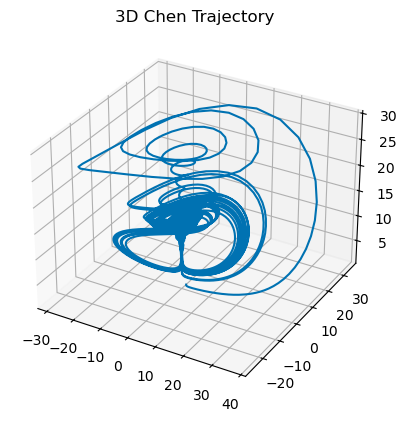

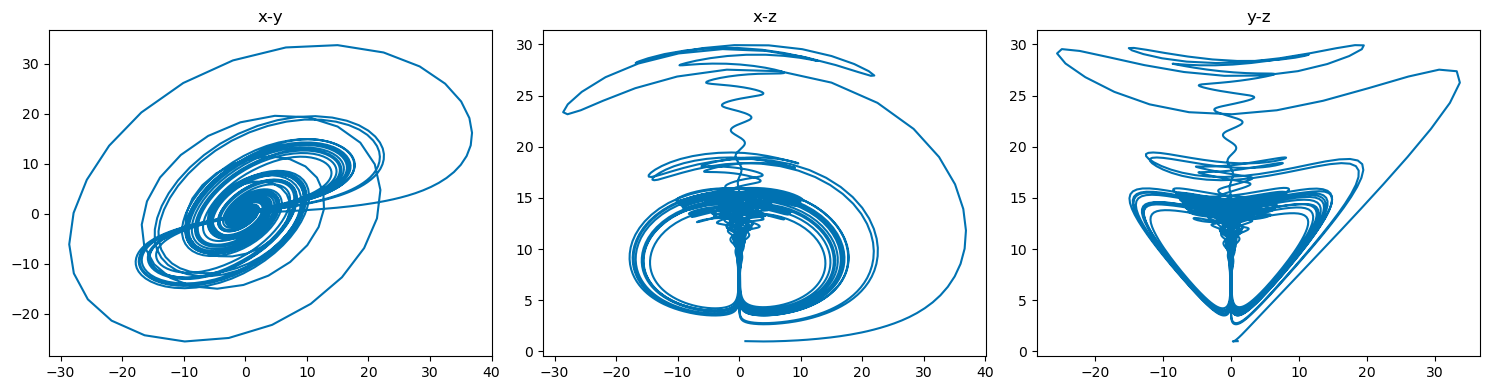

In [3]:
#2b Plotting Chen System in 3D with Subplots
#Plot in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(x,y,z)
ax.set_title('3D Chen Trajectory')
plt.show()

#Projection Subplots
fig, axs = plt.subplots(1,3, figsize=(15,4))

axs[0].plot(x,y)
axs[0].set_title('x-y')

axs[1].plot(x,z)
axs[1].set_title('x-z')

axs[2].plot(y,z)
axs[2].set_title('y-z')

plt.tight_layout()
plt.show()

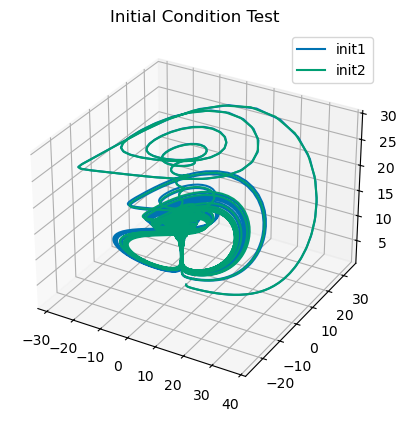

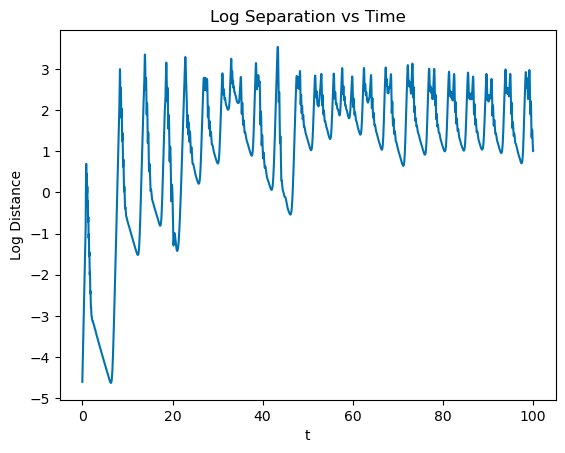

0.2902462459319981


In [4]:
#2c Testing Different Parameters and Estimating Lyapunov Exponent
init1 = [1.0, 1.0, 1.0]
init2 = [1.01, 1.0, 1.0]

#solve_ivp both
sol1 = solve_ivp(chen, t_span, init1, t_eval=t_eval)
sol2 = solve_ivp(chen, t_span, init2, t_eval=t_eval)

x1, y1, z1 = sol1.y
x2, y2, z2 = sol2.y

#3d Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x1,y1,z1, label = "init1")
ax.plot(x2,y2,z2, label = 'init2')

ax.set_title("Initial Condition Test")
ax.legend()
plt.show()

#Lyapunov Estimation
distance = np.sqrt((x1-x2)**2 + (y1-y2)**2 + (z1-z2)**2)

plt.plot(t_eval, np.log(distance))
plt.title("Log Separation vs Time")
plt.xlabel('t')
plt.ylabel('Log Distance')
plt.show()

#Mask Beginning to view Lyapunov Estimate
mask = (t_eval > 0) & (t_eval < 10)
coeffs = np.polyfit(t_eval[mask], np.log(distance[mask]), 1)

lyapunov = coeffs[0]
print(lyapunov) #Positive value = Chaotic system

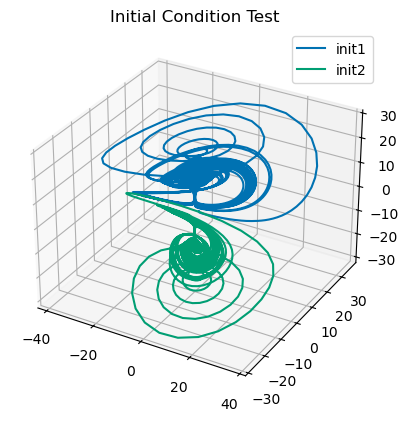

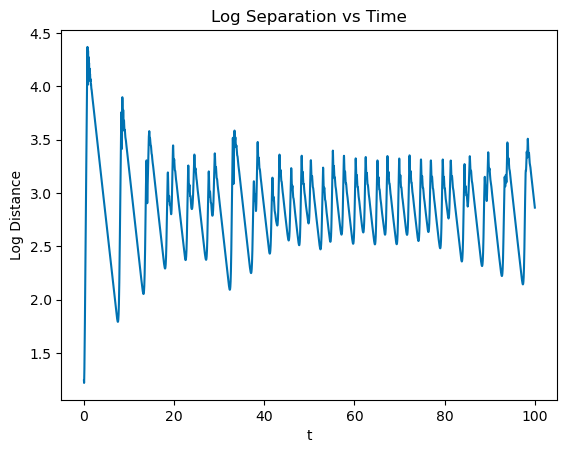

-0.0704449586025074


In [5]:
#2d Negative Chen System Visualization
init1 = [1.0, 1.0, 1.0]
init2 = [-1.0, -1.0, -1.0]

#solve_ivp both
sol1 = solve_ivp(chen, t_span, init1, t_eval=t_eval)
sol2 = solve_ivp(chen, t_span, init2, t_eval=t_eval)

x1, y1, z1 = sol1.y
x2, y2, z2 = sol2.y

#3d Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x1,y1,z1, label = "init1")
ax.plot(x2,y2,z2, label = 'init2')

ax.set_title("Initial Condition Test")
ax.legend()
plt.show()

#Lyapunov Estimation
distance = np.sqrt((x1-x2)**2 + (y1-y2)**2 + (z1-z2)**2)

plt.plot(t_eval, np.log(distance))
plt.title("Log Separation vs Time")
plt.xlabel('t')
plt.ylabel('Log Distance')
plt.show()

#Mask Beginning to view Lyapunov Estimate
mask = (t_eval > 0) & (t_eval < 10)
coeffs = np.polyfit(t_eval[mask], np.log(distance[mask]), 1)

lyapunov = coeffs[0]
print(lyapunov) #Positive  = Chaotic



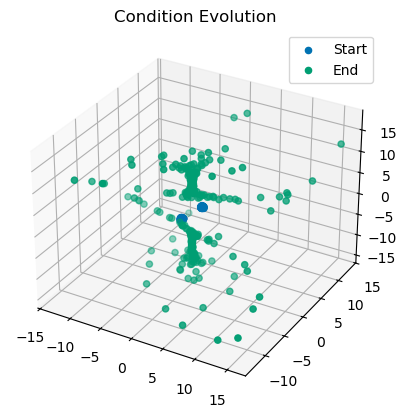

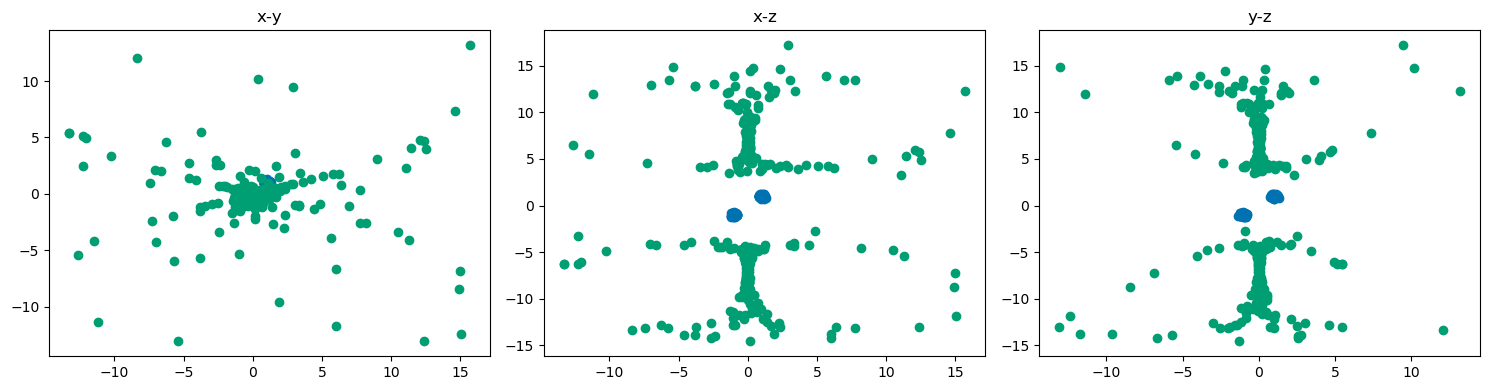

In [9]:
#2e Integrate Trajectories and 3D Projection
#Create intiial conditions
N = 150
spread = 0.1

#Initialize initial points
init_points = []

for _ in range(N):
    init_points.append([1 + spread*np.random.randn(), 1 + spread*np.random.randn(), 1 + spread*np.random.randn()])
    init_points.append([-1 + spread*np.random.randn(), -1 + spread*np.random.randn(), -1 + spread*np.random.randn()])

init_points = np.array(init_points)

#Initialize start and end
start = []
end = []

for i in init_points:
    sol = solve_ivp(chen, t_span, i, t_eval=t_eval)

    start.append(i)
    end.append(sol.y[:, -1]) #End Point

start = np.array(start)
end = np.array(end)

#Plot in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(start[:,0], start[:,1], start[:,2], label = "Start")
ax.scatter(end[:,0], end[:,1], end[:,2], label = "End")
ax.set_title("Condition Evolution")
ax.legend()
plt.show()

#Projections
fig, axs = plt.subplots(1, 3, figsize=(15,4))

axs[0].scatter(start[:,0], start[:,1])
axs[0].scatter(end[:,0], end[:,1])
axs[0].set_title("x-y")

axs[1].scatter(start[:,0], start[:,2])
axs[1].scatter(end[:,0], end[:,2])
axs[1].set_title("x-z")

axs[2].scatter(start[:,1], start[:,2])
axs[2].scatter(end[:,1], end[:,2])
axs[2].set_title("y-z")

plt.tight_layout()
plt.show()

This system displays chaos becuase the trajectories are clustered in the beginning of the simulation (blue dots) and spread out randomly toward the end of the simulation showing chaotic behavior.

In [ ]:
#2f New System Analysis